In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
df = pd.read_csv(r"C:\Users\fariq\Downloads\car data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [2]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.describe()

,Selling_Price,Present_Price,Kms_Driven,Owner,no_year
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,0.043189,10.372093
std,5.082812,8.644115,38886.883882,0.247915,2.891554
min,0.100000,0.320000,500.000000,0.000000,6.000000
25%,0.900000,1.200000,15000.000000,0.000000,8.000000
50%,3.600000,6.400000,32000.000000,0.000000,10.000000
75%,6.000000,9.900000,48767.000000,0.000000,12.000000
max,35.000000,92.600000,500000.000000,3.000000,21.000000


In [8]:
df.isnull().sum()

Car_Name         0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
no_year          0
dtype: int64

In [10]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['car_name', 'selling_price', 'present_price', 'kms_driven', 'fuel_type',
       'seller_type', 'transmission', 'owner', 'no_year', 'current_year'],
      dtype='object')


In [12]:
# Check if 'year' exists before trying to calculate
if 'year' in df.columns:
    df['current_year'] = 2024
    df['no_year'] = df['current_year'] - df['year']

# Use errors='ignore' so it won't crash if the columns are already gone
df.drop(['year', 'current_year', 'car_name'], axis=1, inplace=True, errors='ignore')

df.head()

,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,no_year
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [13]:
df = pd.get_dummies(df, drop_first=True)

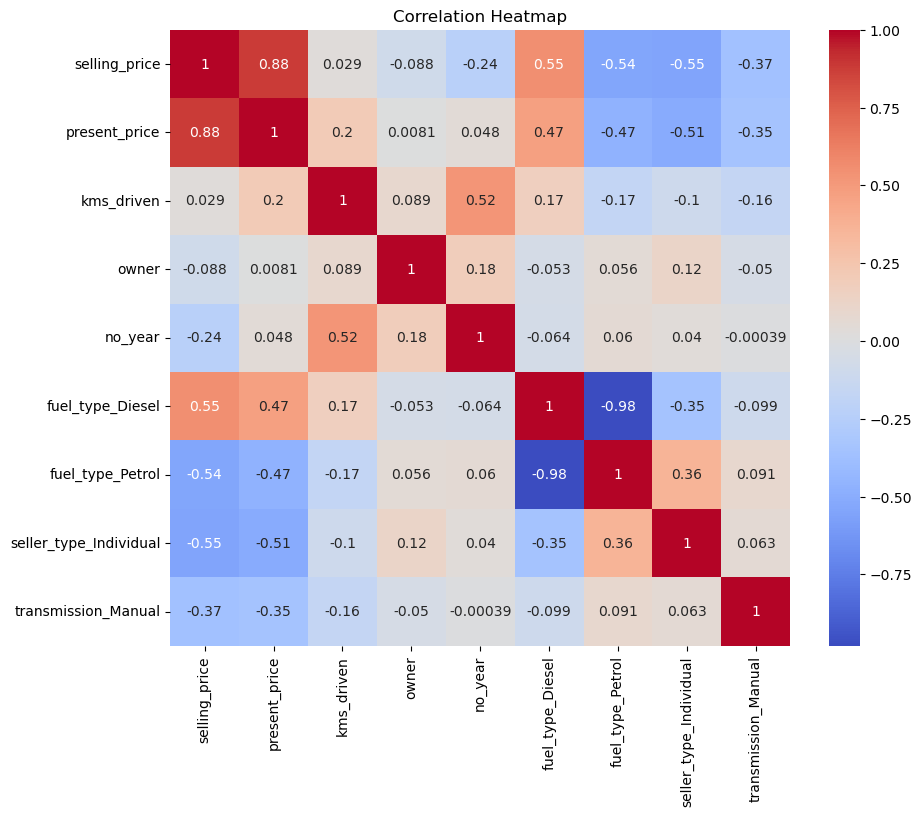

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

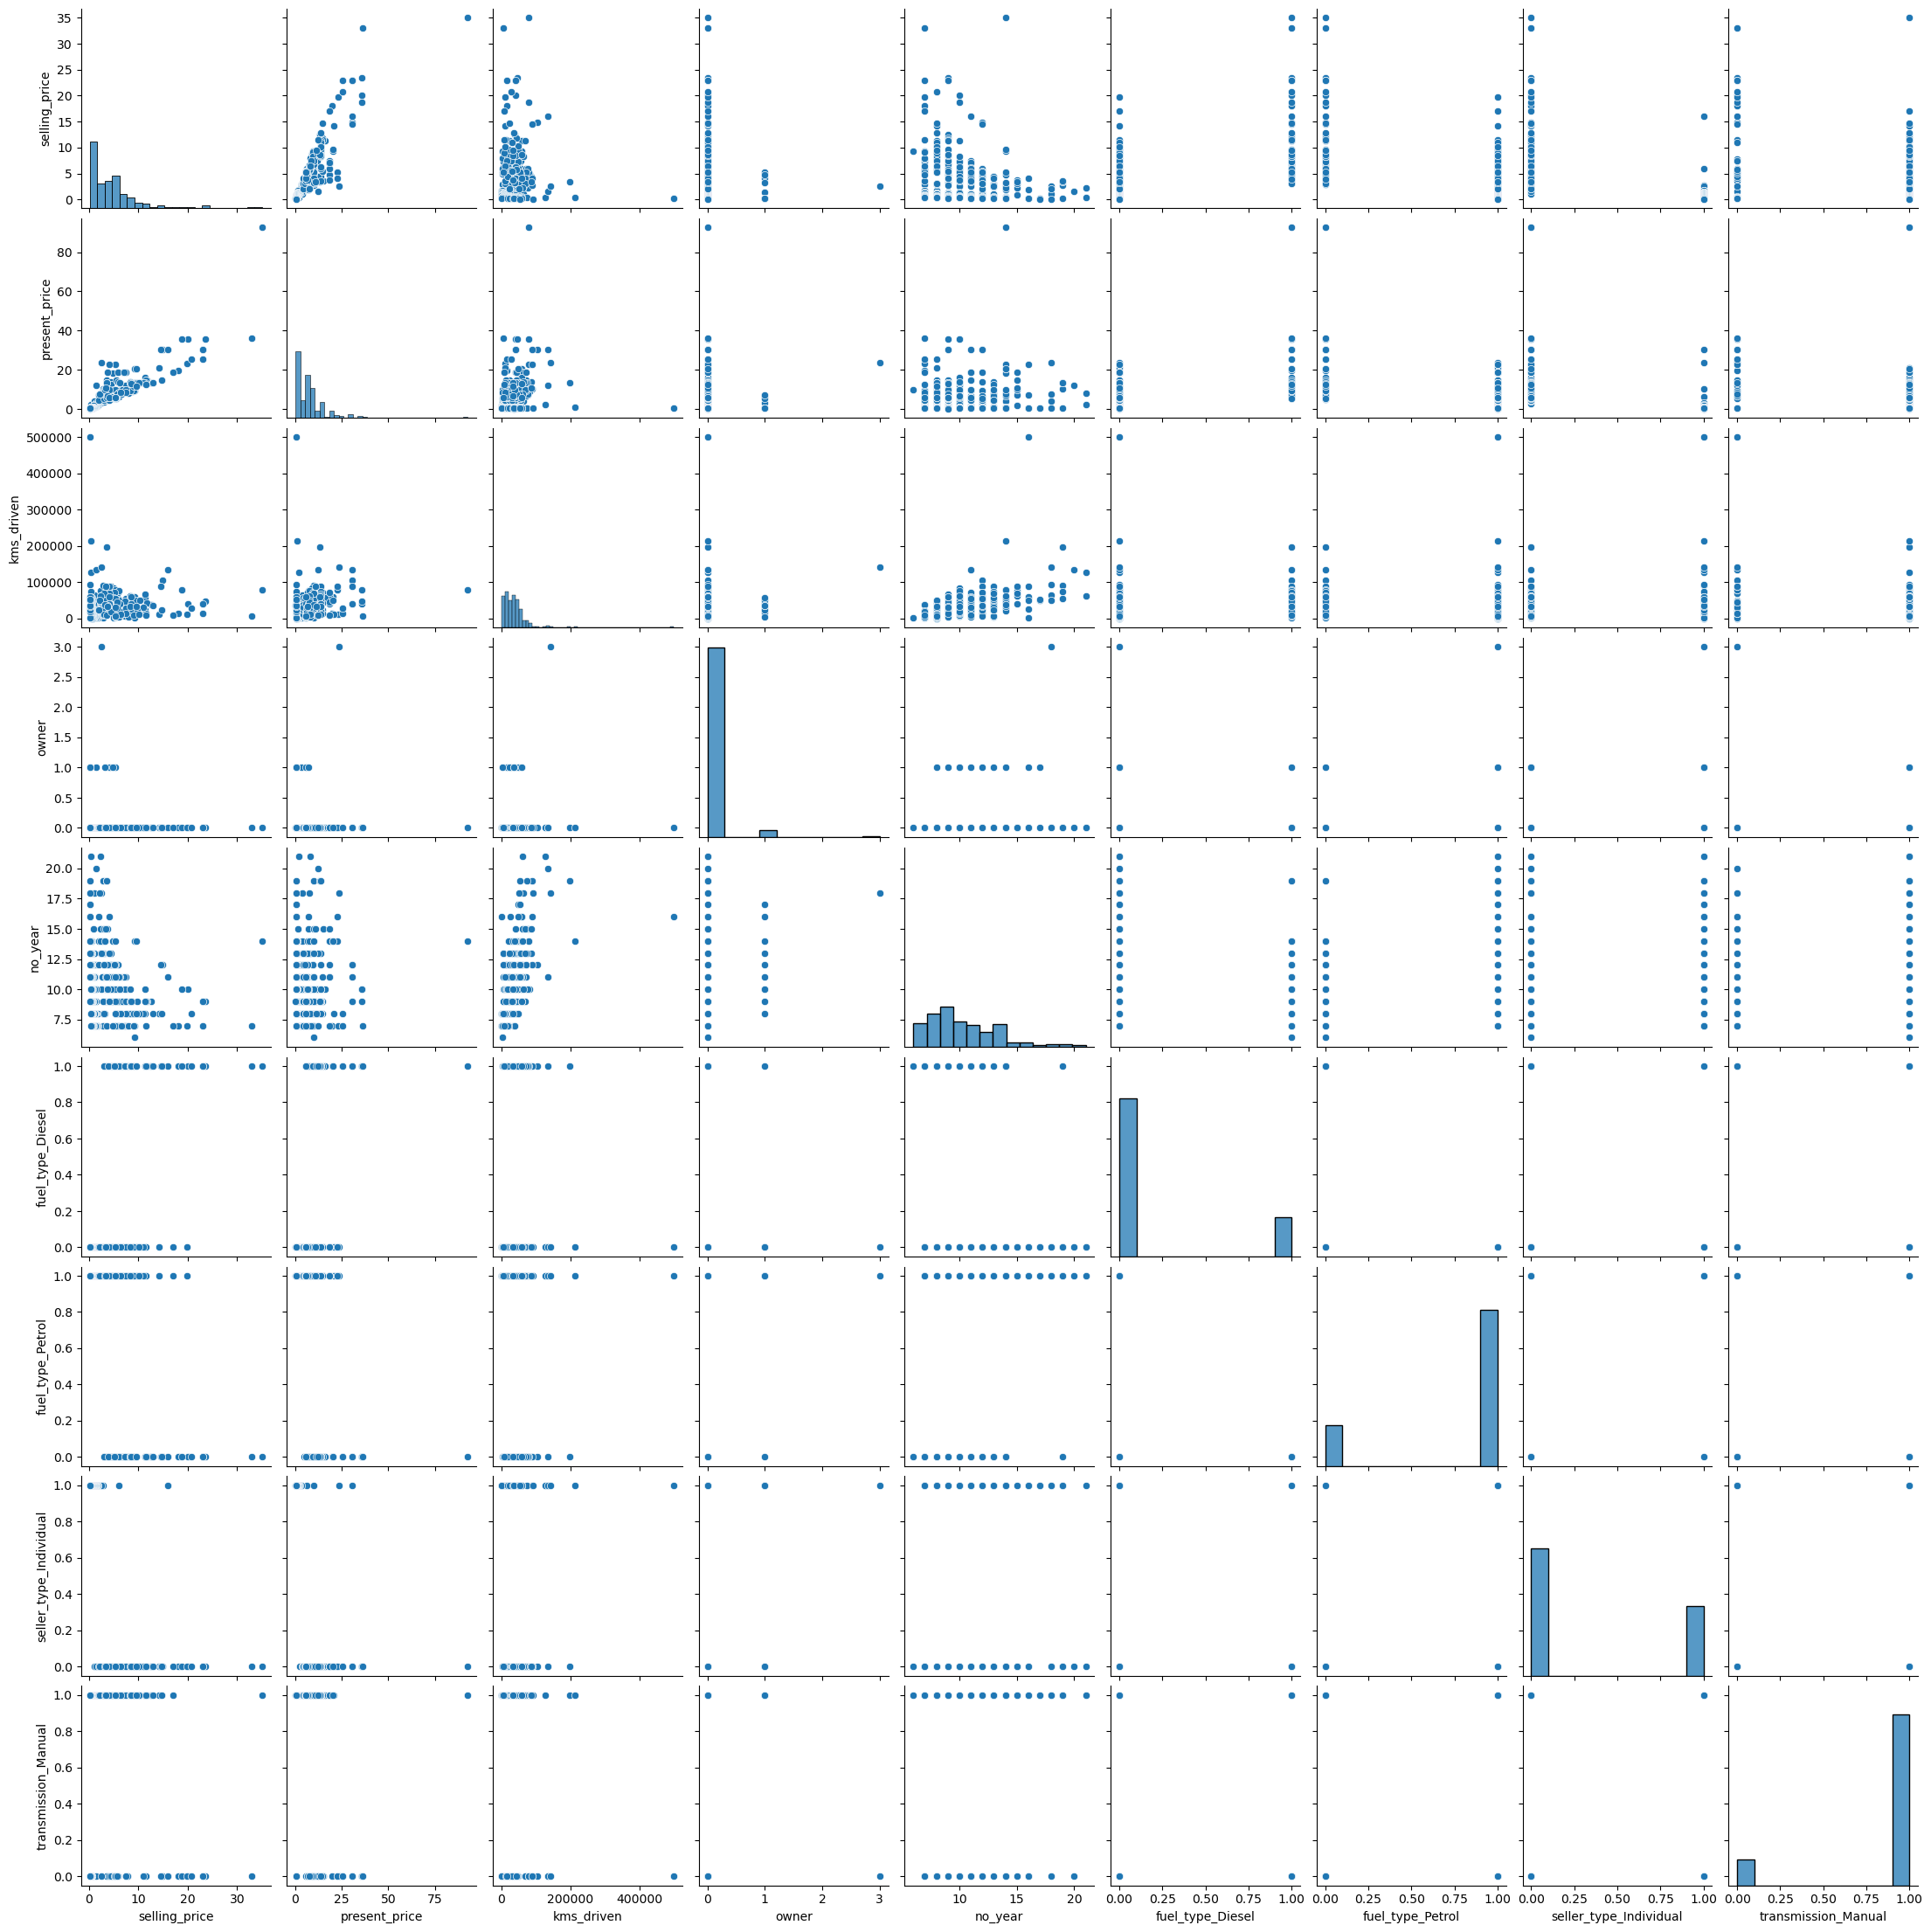

In [17]:
sns.pairplot(df)
plt.show()

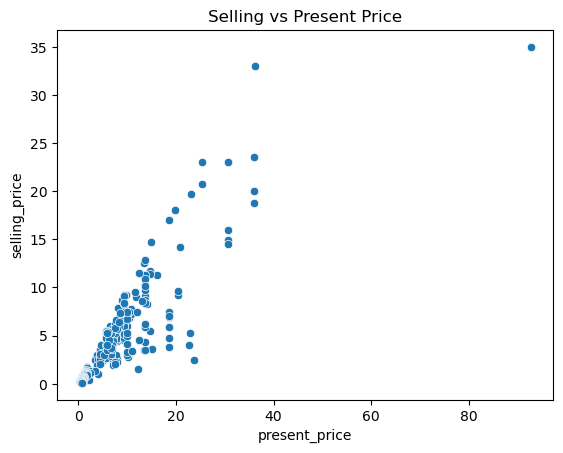

In [18]:
sns.scatterplot(x='present_price', y='selling_price', data=df)
plt.title("Selling vs Present Price")
plt.show()

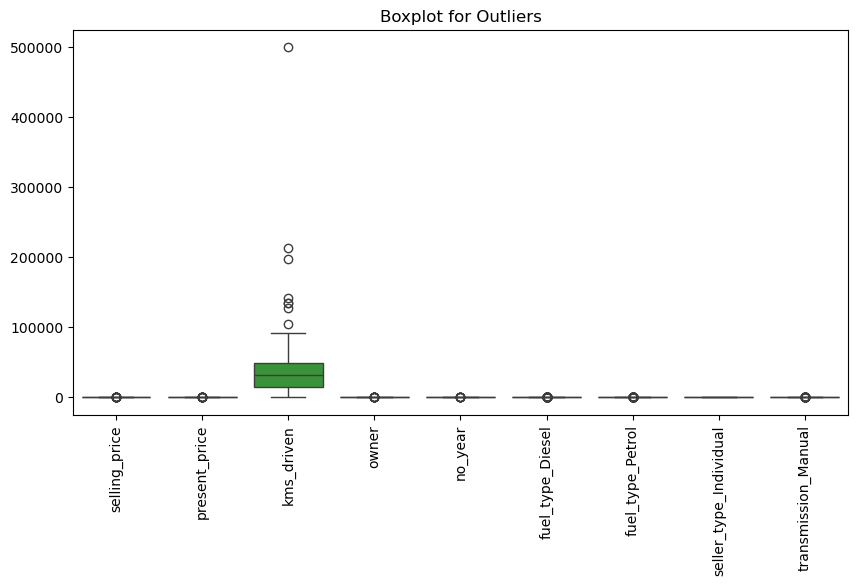

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outliers")
plt.show()

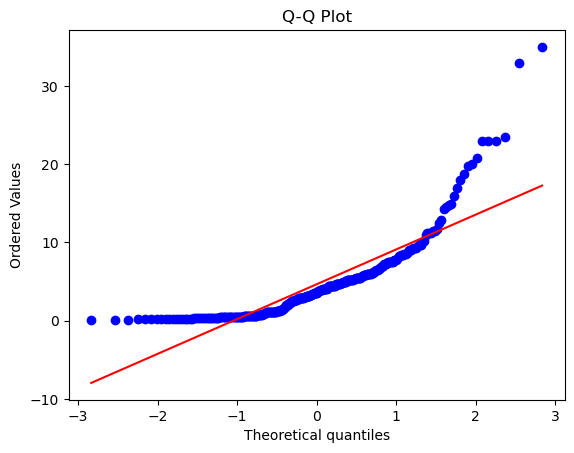

In [20]:
stats.probplot(df['selling_price'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [21]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

Linear Regression R2: 0.8489813024899084
MAE: 1.216225682129699


In [24]:
#decision tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: 0.9102834239490892


In [25]:
#Random forest
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.9578055834087476


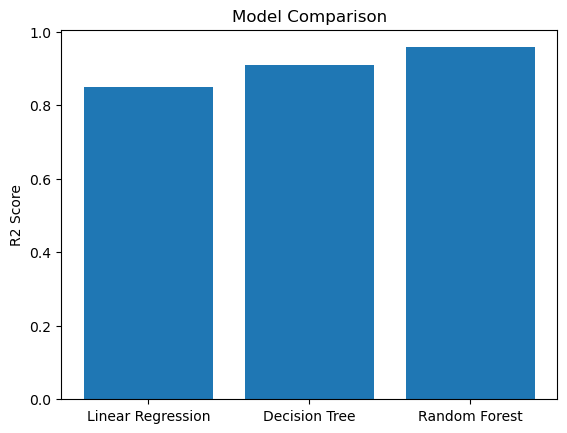

In [26]:
models = ['Linear Regression','Decision Tree','Random Forest']
scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

In [27]:
df.drop(['Car_Name'], axis=1, inplace=True, errors='ignore')

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
#Model Training
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [30]:
#Prediction
predictions = model.predict(X_test)

In [31]:
#Evaluation
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2 Score: 0.9553266551975893
MAE: 0.649578688524591


In [32]:
# --- 1. Categorical Encoding (Safe Version) ---
fuel_map = {'Petrol': 0, 'Diesel': 1, 'CNG': 2}
seller_map = {'Dealer': 0, 'Individual': 1}
trans_map = {'Manual': 0, 'Automatic': 1}

# Use 'if in' to prevent KeyError if the column was already processed or dropped
if 'Fuel_Type' in df.columns and df['Fuel_Type'].dtype == 'object':
    df.replace({'Fuel_Type': fuel_map, 'Seller_Type': seller_map, 'Transmission': trans_map}, inplace=True)

# --- 2. Feature Engineering (Safe Version) ---
if 'Year' in df.columns:
    df['Current_Year'] = 2024
    df['Age'] = df['Current_Year'] - df['Year']
    
    # Drop columns only if they still exist in the dataframe
    cols_to_drop = [c for c in ['Car_Name', 'Year', 'Current_Year'] if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

# --- 3. Defining X and y ---
# If Selling_Price is already gone, X and y must have been defined in a previous run
if 'Selling_Price' in df.columns:
    X = df.drop(['Selling_Price'], axis=1)
    y = df['Selling_Price']

# --- 4. Training the Model ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pickle

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save the model file for the Streamlit app
with open('car_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Success: Model trained and saved as 'car_price_model.pkl'")

Success: Model trained and saved as 'car_price_model.pkl'
